<a href="https://colab.research.google.com/github/RidhoAnfaal/PCVK_Ganjil_2025/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

Mengubah tingkat kecerahan citra
--------------------------------
Masukan nilai kecerahan: 50


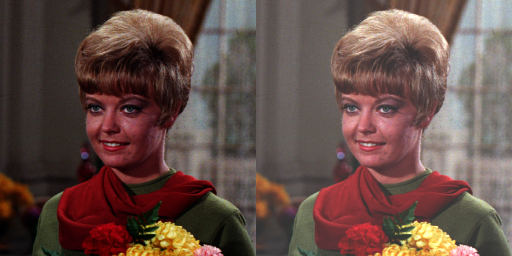

In [ ]:
print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

# for y in range(original.shape[0]):
#   for x in range(original.shape[1]):
#     for c in range(original.shape[2]):
#       brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)

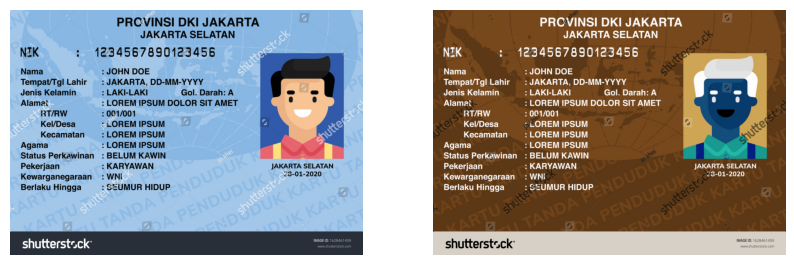

In [6]:
ktp = cv.imread('/content/drive/MyDrive/PCVK/ktp.jpg')

ktp_rgb = cv.cvtColor(ktp, cv.COLOR_BGR2RGB)

# g(x) = 255 - f(x)
ktp_inverted = 255 - ktp_rgb

plt.figure(figsize=(10,10))

plt.subplot(1,2,1)
plt.axis('off')
plt.imshow(ktp_rgb)

plt.subplot(1,2,2)
plt.imshow(ktp_inverted)
plt.axis('off')
plt.show()

Mengubah kontras dan tingkat kecerahan citra
-------------------------------------------
Masukan tingkat kecerahan [-255 - 255]: 50
Masukan kontras [1.0 - 3.0]: 2


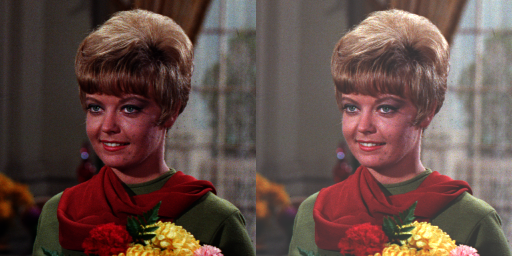

In [7]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('-------------------------------------------')

original_image = cv.imread('/content/drive/MyDrive/PCVK/female.tiff')

try:
  brightness = int(input('Masukan tingkat kecerahan [-255 - 255]: '))
  contrast = float(input('Masukan kontras [1.0 - 3.0]: '))
except ValueError:
  print('Error not number')

# calculate contrast (F)
F = 259.0 * (contrast + 255.0) / (255.0 * (259.0 - contrast))

contrasted_image = F * (original_image.astype(float) - 128) + 128 + brightness

contrasted_image = np.clip(contrasted_image, 0, 255).astype(np.uint8)

final_frame = cv.hconcat([original_image, contrasted_image])
cv2_imshow(final_frame)

Mengubah tingkat kecerahan citra dengan Transformasi Log
-------------------------------------------------------
Masukan nilai kecerahan: 50


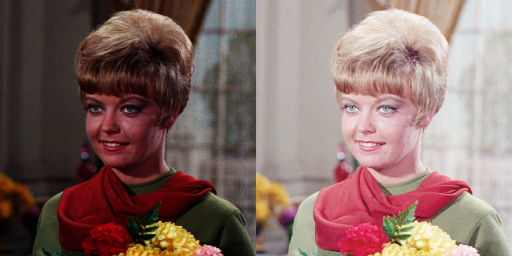

In [8]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('-------------------------------------------------------')

try:
  c = float(input('Masukan nilai kecerahan: '))
except ValueError:
  print('Error, not a number. Using default value.')

r = cv.imread('/content/drive/MyDrive/PCVK/female.tiff')

# g(x) = c * log(1 + f(x))
s = c * np.log(1 + r.astype(float))

# normalize 0-255
max_val = np.max(s)
s = (s / max_val) * 255

s = s.astype(np.uint8)

final_frame = cv.hconcat([r, s])
cv2_imshow(final_frame)

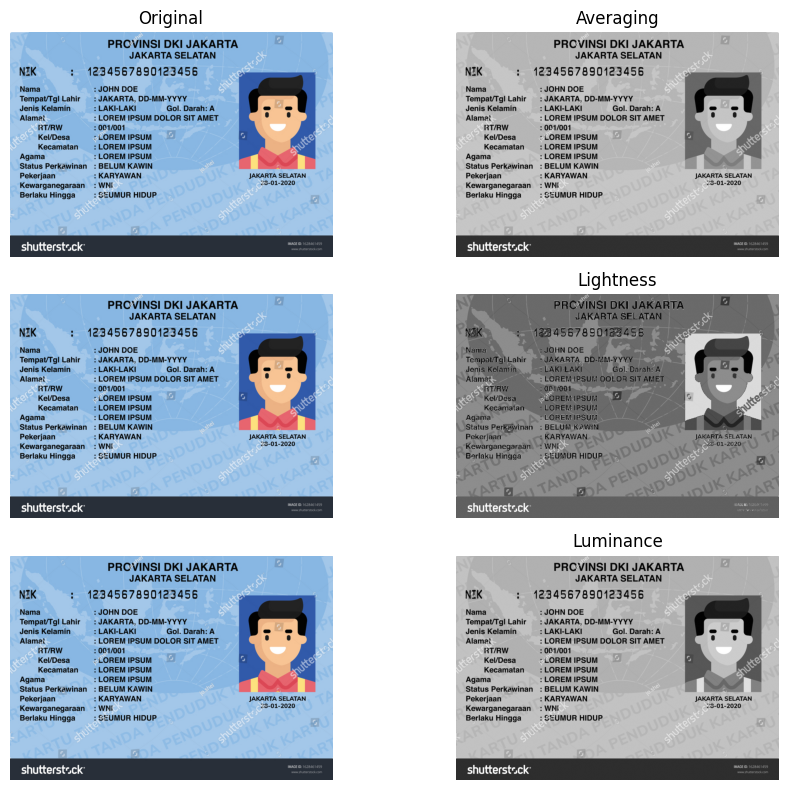

In [11]:
ktp2 = ktp_rgb.copy()

r, g, b = ktp2[:, :, 0], ktp2[:, :, 1], ktp2[:, :, 2]

gray_avg = ((r.astype(float) + g.astype(float) + b.astype(float)) / 3).astype(np.uint8)
gray_lightness = ((np.max(ktp2, axis=2) + np.min(ktp2, axis=2)) / 2).astype(np.uint8)
gray_lum = (0.2126 * r.astype(float) + 0.7152 * g.astype(float) + 0.0722 * b.astype(float)).astype(np.uint8)

plt.figure(figsize=(10, 8))

# averaging
plt.subplot(3, 2, 1)
plt.axis('off')
plt.imshow(ktp2)
plt.title("Original")

plt.subplot(3, 2, 2)
plt.axis('off')
plt.imshow(gray_avg, cmap='gray')
plt.title("Averaging")

# lightness
plt.subplot(3, 2, 3)
plt.axis('off')
plt.imshow(ktp2)

plt.subplot(3, 2, 4)
plt.axis('off')
plt.imshow(gray_lightness, cmap='gray')
plt.title("Lightness")

# luminance
plt.subplot(3, 2, 5)
plt.axis('off')
plt.imshow(ktp2)

plt.subplot(3, 2, 6)
plt.axis('off')
plt.imshow(gray_lum, cmap='gray')
plt.title("Luminance")

plt.tight_layout()
plt.show()

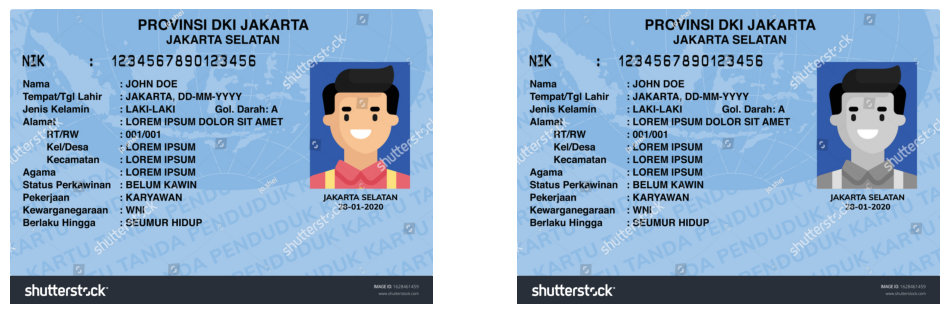

In [16]:
ktp3 = cv.imread('/content/drive/MyDrive/PCVK/ktp.jpg')
ktp_rgb2 = cv.cvtColor(ktp3, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(ktp_rgb2, cv.COLOR_RGB2GRAY)

gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)
blue_mask = (ktp_rgb2[:, :, 2] > ktp_rgb2[:, :, 0]) & (ktp_rgb2[:, :, 2] > ktp_rgb2[:, :, 1])
color_splash = gray_3ch.copy()
color_splash[blue_mask] = ktp_rgb2[blue_mask]

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(ktp_rgb2)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(color_splash)
plt.axis("off")

plt.show()